In [ ]:
from agents import Agent, Runner, function_tool, ItemHelpers


@function_tool
def get_weather(city: str):
    """도시별 날씨 받아오기"""
    return f"30 degrees"

agent = Agent(
    name="Assistant Agent",
    instructions="You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather],
)

steam = Runner.run_streamed(agent, "안녕 일본의 수도 날씨는 어때??")

async for event in steam.stream_events():    
    if event.type == "raw_response_event":
        continue
    elif event.type == "agent_updated_stream_event":
        print("Agent updated to", event.new_agent.name)
    elif event.type == "run_item_stream_event":
        if event.item.type == "tool_call_item":
            print(event.item.raw_item.to_dict())
        elif event.item.type == "tool_call_output_item":
            print(event.item.output)
        elif event.item.type == "message_output_item":
            print(ItemHelpers.text_message_output(event.item))


    print("="*20)

Agent updated to Assistant Agent
{'arguments': '{"city":"도쿄"}', 'call_id': 'call_b2Zwh7KFSuj59WJfXpEEb7UM', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_08d0c6d472882a6d006985a8f143bc8190af0b15eb3105e677', 'status': 'completed'}
30 degrees
일본의 수도 도쿄의 현재 날씨는 30도입니다. 덥네요! 다른 정보가 궁금하신가요?


In [ ]:
from agents import Agent, Runner, function_tool, ItemHelpers

@function_tool
def get_weather(city: str):
    """도시별 날씨 받아오기"""
    return f"30 degrees"

agent = Agent(
    name="Assistant Agent",
    instructions="You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather],
)

steam = Runner.run_streamed(agent, "안녕 일본의 수도 날씨는 어때??")

message = ""
args = ""

async for event in steam.stream_events():    
    if event.type == "raw_response_event":
        event_type = event.data.type
        if event_type == "response.output_text.delta":
            message += event.data.delta
            print(message)
        elif event_type == "response.function_call_arguments.delta":
            args += event.data.delta
            print(args)
        elif event_type == "response.completed":
            message = ""
            args = ""



In [3]:

from agents import Agent, Runner, function_tool, SQLiteSession 

session = SQLiteSession("user_2", "ai-memory.db")

@function_tool
def get_weather(city: str):
    """도시별 날씨 받아오기"""
    return f"30 degrees"

agent = Agent(
    name="Assistant Agent",
    instructions="You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather],
)

In [19]:
result = await Runner.run(
    agent, 
    "근데 내 이름이 뭐였는지 기억하고 있어?",
    session=session
    )

print(result.final_output)

네가 이전에 이름을 말해 준 적이 있다면 기억할 수 있지만, 이번 대화에서 아직 네 이름을 알려주지 않았어. 네 이름을 알려주면 앞으로 기억해서 부를 수 있어! 이름이 뭐야?


In [18]:
await session.pop_item()

{'role': 'user', 'content': 'My name is sam'}

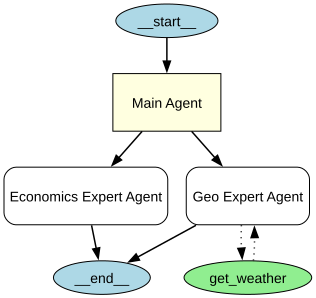

In [3]:
from agents import Agent, function_tool, Runner, SQLiteSession, function_tool, trace
from agents.extensions.visualization import draw_graph
import os
from pydantic import BaseModel

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

session = SQLiteSession("user_11", "ai-memory.db")

class Answer(BaseModel):
    answer: str
    background_explanation: str


@function_tool
def get_weather(city: str):
    """도시별 날씨 받아오기"""
    return f"30 degrees"

geaography_agent = Agent(
    name="Geo Expert Agent",
    instructions="너는 지리학 전문가야 지리와 관련된 질문에 답변을 해줘" ,
    handoff_description="지리학 관련 질문에 답할 때 이걸 사용해",
    tools=[get_weather],
    output_type=Answer
)

economics_agent = Agent(
    name="Economics Expert Agent",
    instructions="너는 경제학 전문가야 경제와 관련된 질문에 답변을 해줘" ,
    handoff_description="경제학 관련 질문에 답할 때 이걸 사용해"
)

main_agent = Agent(
    name="Main Agent",
    instructions="너는 사용자 인터페이스 angent고, 사용자의 질문에 답변하는 데에 있어서 가장 적합한 agent에게 작업을 넘겨줘",
    handoffs=[
        economics_agent,
        geaography_agent
    ]
)

draw_graph(main_agent)

In [4]:
with trace("user_11"):
    result = await Runner.run(
        main_agent, 
        "태국의 북부 지방의 주도는 뭐야?",
        session=session
        )
    result = await Runner.run(
        main_agent, 
        "스위스의 북부 지방의 주도는 뭐야?",
        session=session
        )
    result = await Runner.run(
        main_agent, 
        "한국의 북부 지방의 주도는 뭐야?",
        session=session
        )        

    print(result.last_agent.name)
    print(result.final_output)

Geo Expert Agent
answer='한국의 북부 지방을 대표하는 주도는 서울입니다. 서울은 한반도 북부에 위치해 있으며, 대한민국의 수도이자 가장 큰 도시로, 행정, 정치, 경제, 문화의 중심지입니다.' background_explanation='한국은 공식적으로 남북으로 \'북부 지방\'과 같이 행정구역이 나뉘진 않지만, 지리적으로 한반도의 중북부에 위치한 서울이 북부 지역을 대표하는 도시로 여겨집니다. 실제로 서울은 국토의 중부에서 약간 북쪽에 위치해 있고, 주변의 경기도, 인천 등과 함께 수도권으로 불리며 모든 면에서 중심 역할을 합니다. "주도"란 표현은 시·도를 대표하는 행정 중심 도시를 의미하지만, 북부 지방이라는 큰 구분에서 본다면 서울이 대표적입니다.'
